In [9]:
import glob
import os
import numpy as np
import pandas as pd
import scipy.signal
import skimage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu
from matplotlib.pyplot import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import random

plt.style.use('styleNB.mplstyle')


In [4]:
# Migration track data
df = pd.read_csv('../../data/processed_2D_tracking/20250527_MDCK_filtered_tracks_compiled.csv')

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'scope', 'position', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 15:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'scope': g[5],
            'position': g[6],
            'cell': g[7],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)


df_filtered_tracks.celltype.unique()
df = df_filtered_tracks

# Flow cytometry data
files = glob.glob('../../data/flow_cytometry/20250514_MDCK/*.fcs')



In [5]:
dict_EF = {'0' : 0, 
           '3' : 1}

# Plotting of MDCK data (300 mV/mm condition only)

Note that 'CR01-low' is the MDCK cell line expressing the lower level of Galvanin-GFP, while CR02-high is expressing the highest level of Galvanin-GFP.

## Tracks

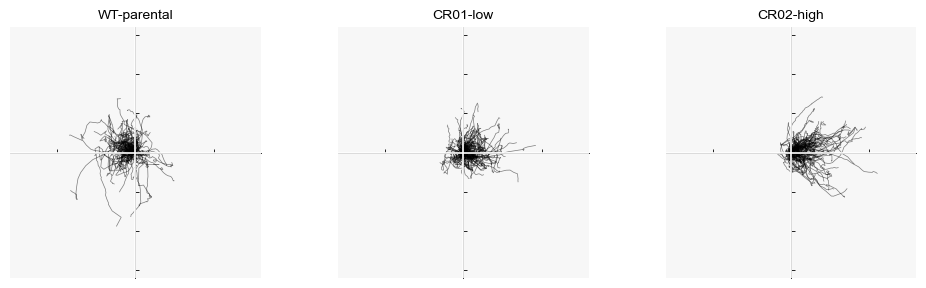

In [7]:


fig = plt.figure(figsize=(10, 3))  # Wider figure for horizontal layout
gs = GridSpec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

xlim = (-160, 160)
ylim = (-160, 160)
track_color = 'k'

# Define celltypes and titles
celltypes = ['WT-parental', 'CR01-low', 'CR02-high']
axes = []

for i, celltype in enumerate(celltypes):
    ax = fig.add_subplot(gs[0, i])
    df_temp = df[(df.celltype == celltype) & (df.E_V_cm == 3)]
    count_cell = 0

    for _, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):
        if len(d_.frame) < 30:
            continue
        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if np.shape(t0_x) == (0,) or len(d_.x.values) != len(d_.y.values):
            continue
        ax.plot(d_.x - t0_x, d_.y - t0_y, color=track_color, alpha=0.5, lw=0.5, zorder=20)
        count_cell += 1
        if count_cell > 100:
            break

    # Standard formatting
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_axisbelow(True)
    ax.set_facecolor('#f7f7f7')
    ax.axhline(0, color='white', lw=1.2, zorder=100)
    ax.axvline(0, color='white', lw=1.2, zorder=100)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['bottom'].set_position(('data', 0))
    ax.xaxis.set_label_coords(0.6, -0.05)
    ax.yaxis.set_label_coords(0.0, 0.6)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(length=3)
    ax.set_title(celltype, fontsize=10)

    axes.append(ax)

plt.tight_layout()
# plt.savefig('track_plots_row.pdf', bbox_inches='tight')
plt.show()

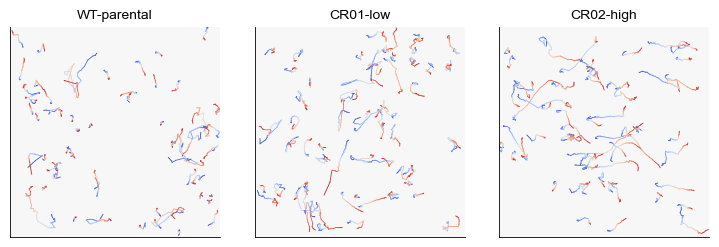

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Filter to E_V_cm == 3
df_sub = df_filtered_tracks[df_filtered_tracks['E_V_cm'] == 3].copy()

# Extract sorted unique celltypes
celltypes = ['WT-parental', 'CR01-low', 'CR02-high']
celltype_dict = {ct: i for i, ct in enumerate(celltypes)}

n_rows = 1
n_cols = len(celltypes)

# Image scale and plotting parameters
ip = 0.642
n_cells_per_group = 60
cmap = plt.get_cmap('coolwarm')

# Initialize subplots: 1 row, multiple columns (one per celltype)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 2.5), squeeze=False)

for celltype, d in df_sub.groupby('celltype'):
    c = celltype_dict[celltype]
    ax_ = ax[0, c]

    # Filter and retain only valid cells fully within the specified bounds
    valid_cells = []
    for _, d_ in d.groupby(['cell', 'trial', 'date', 'user', 'position']):


        x = d_.x.values - 1024.0 * ip
        y = 1024.0 * ip - d_.y.values

        within_x = np.logical_and(x >= -400, x <= -100)
        within_y = np.logical_and(y >= 100, y <= 400)
        if np.all(np.logical_and(within_x, within_y)):
            valid_cells.append(d_)

    if not valid_cells:
        continue

    # Sample up to N cells
    random.seed(15)
    sampled_cells = random.sample(valid_cells, min(len(valid_cells), n_cells_per_group))

    # Plot each sampled trajectory
    for d_ in sampled_cells:
        x = d_.x.values - 1024.0 * ip
        y = 1024.0 * ip - d_.y.values
        time = np.arange(len(x))
        norm_time = (time - np.min(time)) / (np.max(time) - np.min(time))

        for i in range(len(x) - 1):
            ax_.plot(x[i:i+2], y[i:i+2], color=cmap(norm_time[i]), linewidth=0.6)

    # Formatting
    ax_.set_aspect('equal')
    ax_.set_facecolor('#f7f7f7')
    ax_.set_xticks([])
    ax_.set_yticks([])
    ax_.set_xlim(-400, -100)
    ax_.set_ylim(100, 400)
    ax_.tick_params(left=False, bottom=False)
    ax_.set_title(celltype, fontsize=10)

plt.tight_layout()
# plt.savefig("trajectories_EF3_row.pdf", bbox_inches='tight')
plt.show()